In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Task 21: Manual Convolution

Before using `Conv2D`, implement the convolution operation manually using NumPy.

1. Implement `make_square_image(size=28)`. The function returns a black 28×28 image with a white square centered in the middle.
2. Implement `conv2d(image, kernel, stride, padding)` that slides the filter over the image and computes the sum of element-wise products. Use only NumPy without any built-in convolution routines.
3. Define a dictionary of 3×3 filters: `vertical_edge`, `horizontal_edge`, `blur`, and `sharpen`.
4. Implement `plot_images(images, titles)` to display the original input image side-by-side with the output of each filter.
5. Verify the output shape across four combinations: padding of 0 or 1, and stride of 1 or 2.

### Questions to answer:
- What is the general formula for the output dimensions?
- What feature does each filter detect?
- Why does the `vertical_edge` output contain both positive and negative values?

1. Implement `make_square_image(size=28)`. The function returns a black 28×28 image with a white square centered in the middle.


In [2]:
def make_square_image(size=28):
    img = np.zeros((size, size))      # black image: size x size array of zeros

    s = 12                            # side length of the white square
    start = (size - s) // 2           # index where the square begins
                                      # (equal black margin on both sides)

    img[start:start + s, start:start + s] = 1

    return img 

2. Implement `conv2d(image, kernel, stride, padding)` that slides the filter over the image and computes the sum of element-wise products. Use only NumPy without any built-in convolution routines.

In [3]:
def conv2d(image, kernel, stride=1, padding=0):
    # step 1: add a frame of zeros around the image (padding=0 -> no change)
    image = np.pad(image, padding)

    # step 2: size of the output
    k = kernel.shape[0]                              # kernel size (e.g. 3)
    out_h = (image.shape[0] - k) // stride + 1       # how many windows fit vertically
    out_w = (image.shape[1] - k) // stride + 1       # how many windows fit horizontally

    # step 3: empty output, we will fill it cell by cell
    result = np.zeros((out_h, out_w))

    # step 4: slide the window over the image
    for i in range(out_h):                           # i = row index of the output
        for j in range(out_w):                       # j = column index of the output
            top = i * stride                         # first row of the window in the image
            left = j * stride                        # first column of the window in the image

            # cut a k x k piece of the image (the current window)
            window = image[top:top + k, left:left + k]

            # multiply window and kernel cell by cell, sum everything into one number
            result[i, j] = np.sum(window * kernel)

    # step 5: return the finished output (feature map)
    return result

In [4]:
img = np.array([[1,1,1,0,0]] * 5)
flt = np.array([[1,0,-1]] * 3)
print(conv2d(img, flt))

[[0. 3. 3.]
 [0. 3. 3.]
 [0. 3. 3.]]


3. Define a dictionary of 3×3 filters: `vertical_edge`, `horizontal_edge`, `blur`, and `sharpen`.

In [5]:
filters = {
    # compares left column with right column -> reacts to vertical edges
    "vertical_edge": np.array([[1, 0, -1],
                               [1, 0, -1],
                               [1, 0, -1]]),

    # compares top row with bottom row -> reacts to horizontal edges
    # (same as vertical_edge, just transposed)
    "horizontal_edge": np.array([[ 1,  1,  1],
                                 [ 0,  0,  0],
                                 [-1, -1, -1]]),

    # average of 9 neighbours: 9 equal weights of 1/9, sum = 1
    "blur": np.ones((3, 3)) / 9,

    # boosts the centre pixel, subtracts the 4 direct neighbours, sum = 1
    "sharpen": np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]]),
}

In [6]:
for name, f in filters.items():
    print(name, f.sum())

vertical_edge 0
horizontal_edge 0
blur 1.0
sharpen 1


4. Implement `plot_images(images, titles)` to display the original input image side-by-side with the output of each filter.

In [7]:
def plot_images(images, titles):
    n = len(images)                                   # how many images to show

    # one row with n slots side by side
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))

    for ax, img, title in zip(axes, images, titles):  # go through slots, images, titles together
        ax.imshow(img, cmap="gray")                   # draw the 2D array as a grayscale image
        ax.set_title(title)                           # name above the image
        ax.axis("off")                                # hide the axis numbers

    plt.tight_layout()                                # avoid overlapping titles
    plt.show()

5. Verify the output shape across four combinations: padding of 0 or 1, and stride of 1 or 2.

In [8]:
img = make_square_image()
flt = filters["vertical_edge"]

for p in (0, 1):                       # padding values
    for s in (1, 2):                   # stride values
        out = conv2d(img, flt, stride=s, padding=p)
        print(f"padding={p}, stride={s} -> shape {out.shape}")

padding=0, stride=1 -> shape (26, 26)
padding=0, stride=2 -> shape (13, 13)
padding=1, stride=1 -> shape (28, 28)
padding=1, stride=2 -> shape (14, 14)


(28 + 0(2*padding) -3(filtr)) //1(stride) + 1 = 26

(28 + 0(2*padding) -3(filtr)) //2(stride) + 1 = 13

(28 + 2(2*padding) -3(filtr)) //1(stride) + 1 = 28

(28 + 2(2*padding) -3(filtr)) //2(stride) + 1 = 14

### Questions to answer:
- What is the general formula for the output dimensions?
- What feature does each filter detect?

1. The output size is (n + 2p − k) // s + 1, where n is the input size, p is the padding, k is the kernel size and s is the stride. We add the padding to both sides of the input (hence 2p), subtract the kernel size (because the window has to fit inside the image), divide by the stride and round down, and then add 1 (for the first window position).
2.
  vertical edge   -> finds vertical edges (left-right brightness change)
  
  horizontal edge -> finds horizontal edges (top-bottom brightness change)
  
  blur            -> smooths the image by averaging neighbors, reduces noise
  
  sharpen         -> amplifies differences from neighbors, makes details crisper

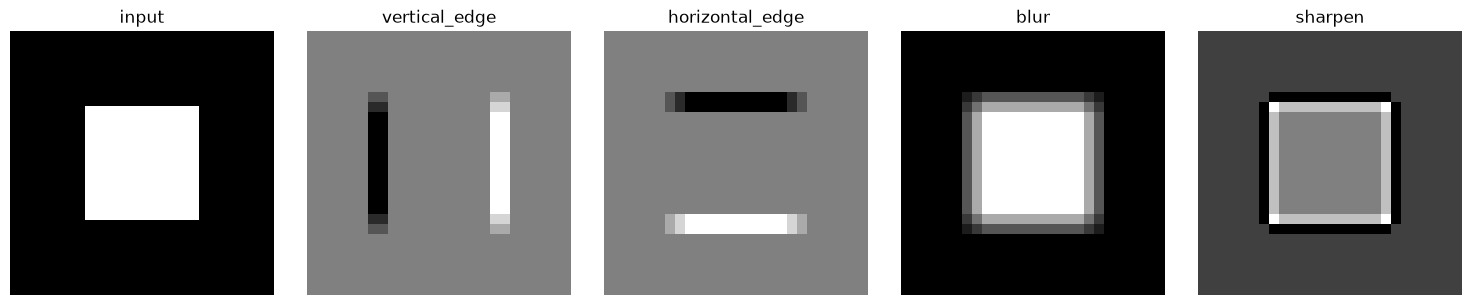

In [9]:
2. 
img = make_square_image()

images = [img]
titles = ["input"]
for name, f in filters.items():
    images.append(conv2d(img, f))
    titles.append(name)

plot_images(images, titles)

# Task 22: The Conv2D Layer and Its Parameters

The exact same operation, but now executed by a neural network layer.

- Build a model with a single layer: `Conv2D` with 1 filter of size 3×3, no activation function, accepting an input image of shape `28×28×1`.
- Call `summary()` (or calculate parameters manually in PyTorch) and record the parameter count.
- Change the number of filters to 8, and then additionally increase the number of input channels to 3. Record the parameter count for each configuration.
- Manually assign the `vertical_edge` weights and a bias of 0 to the layer. Compare the layer's output with your custom `conv2d` function from Task 21 using `np.allclose`.
- Compare the output shapes for `padding='valid'` versus `padding='same'` (in PyTorch, these correspond to `padding=0` and `padding=1`).

### Questions to answer:
- Where do these parameter counts come from?
- Why is the parameter count independent of the image resolution/size?
- How many parameters would a `Dense` layer have if it mapped 784 input pixels to 784 output values?

Build a model with a single layer: `Conv2D` with 1 filter of size 3×3, no activation function, accepting an input image of shape `28×28×1`.

Call `summary()` (or calculate parameters manually in PyTorch) and record the parameter count.

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D
from tensorflow.keras.layers import MaxPooling2D

In [11]:
Model_1 = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(filters=1, kernel_size=(3, 3))
    ])
Model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 1)      │            10 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10 (40.00 B)

 Trainable params: 10 (40.00 B)

 Non-trainable params: 0 (0.00 B)

 1 filter,  1 input channel  -> 10 params   (3* 3 * 1 weights + 1 bias)


- Change the number of filters to 8, and then additionally increase the number of input channels to 3. Record the parameter count for each configuration.

In [12]:
Model_2 = Sequential([
    Input(shape=(28, 28, 3)),
    Conv2D(filters=8, kernel_size=(3,3))
    ])
Model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 8)      │           224 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 224 (896.00 B)

 Trainable params: 224 (896.00 B)

 Non-trainable params: 0 (0.00 B)

8 filters, 3 input channels -> 224 params  (8 * (3 * 3 * 3 + 1))


- Manually assign the `vertical_edge` weights and a bias of 0 to the layer. Compare the layer's output with your custom `conv2d` function from Task 21 using `np.allclose`.

In [13]:
vertical_edge = np.array([[1, 0, -1],
                          [1, 0, -1],
                          [1, 0, -1]], dtype=np.float32)

# 1. layer with random weights
Model_3 = Sequential([Input(shape=(10, 10, 1)), Conv2D(1, (3, 3))])

# 2. set the weights by hand
# Keras weight shape is (kernel_h, kernel_w, in_channels, filters) = (3, 3, 1, 1)
# bias shape is (filters,) = (1,)
Model_3.layers[0].set_weights([vertical_edge.reshape(3, 3, 1, 1), np.zeros(1)])

# 3. run the same image through both
image = np.random.rand(10, 10).astype(np.float32)

keras_out = Model_3.predict(image.reshape(1, 10, 10, 1))   # input needs shape (batch, H, W, channels)
keras_out = keras_out.reshape(8, 8)                      # drop batch and channel dims -> (8, 8)

my_out = conv2d(image, vertical_edge)                    # your function from Task 21

# 4. compare
print(np.allclose(keras_out, my_out))                    # expected: True

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
True


 Summary:
 We build a Keras Conv2D layer (1 filter, 3x3) for a 10x10 grayscale image and replace its
 
 random starting weights with the vertical-edge kernel and a bias of 0.
 
 Then we run the same random image through the Keras layer and through our own
 
 conv2d function from Task 21, and compare the two outputs with np.allclose.
 
 If they match, it proves that a Conv2D layer is just a filter sliding over the image,
 
 the same operation we implemented by hand. The only difference is that in a real network
 
 the filter values are learned during training instead of being set manually.

- Compare the output shapes for `padding='valid'` versus `padding='same'` (in PyTorch, these correspond to `padding=0` and `padding=1`)

In [14]:
model_valid = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(1, (3, 3), padding="valid")
])

model_same = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(1, (3, 3), padding="same")
])

print(model_valid.output_shape)
print(model_same.output_shape)

(None, 26, 26, 1)
(None, 28, 28, 1)


 padding="valid": no padding, the filter stays inside the image, so the output shrinks: 28 - 3 + 1 = 26 -> output shape (26, 26, 1)
 
padding="same": a border of zeros is added around the image,so the output keeps the input size: 28 -> output shape (28, 28, 1)
 
The parameter count is the same in both cases (10 = 3*3 weights + 1 bias),because padding changes how the filter slides, not the filter itself.

- Where do these parameter counts come from?
- Why is the parameter count independent of the image resolution/size?
- How many parameters would a `Dense` layer have if it mapped 784 input pixels to 784 output values?

1. They come from the formula:
       params = (kernel_height * kernel_width * input_channels + 1) * num_filters
   Each filter has kernel_height * kernel_width weights for every input channel,
   plus 1 bias. This is repeated for every filter.
   - 1 filter,  1 channel:   (3 * 3 * 1 + 1) * 1 = 10
   - 8 filters, 1 channel:   (3 * 3 * 1 + 1) * 8 = 80
   - 8 filters, 3 channels:  (3 * 3 * 3 + 1) * 8 = 224


2. Because the same small filter (here 3x3 = 9 weights) slides over the whole image.
   The weights are shared across all positions, so a 1000x1000 image and a 28x28 image
   use exactly the same number of parameters. Only the size of the output changes,
   not the number of weights.


3. Every input is connected to every output with its own weight, and each output
   neuron has one bias:
       784 * 784 + 784 = 614,656 + 784 = 615,440 parameters
   That is over 60,000 times more than Conv2D(1, (3, 3)), which has only 10.

# Task 23: Pooling and Shape Tracking

Observe how the image transforms as it passes through sequential layers.

- Implement `pool2d(image, size, mode)` in NumPy supporting `"max"` and `"avg"` modes. Apply it to the `vertical_edge` output from Task 21 and plot both resulting images side-by-side.
- Build the following model architecture: `Conv2D(8, (3, 3), activation='relu')` → `MaxPooling2D(2)` → `Conv2D(16, (3, 3), activation='relu')` → `MaxPooling2D(2)` → `Flatten` → `Dense(10)`.
- Implement `print_layer_shapes(model)` to display the output shape and parameter count for each layer.
- Calculate all output shapes on paper before executing the code, then verify against the model summary.
- For comparison, construct an MLP baseline: `Flatten` → `Dense(64)` → `Dense(10)`, and compare the total parameter count between both architectures.

### Questions to answer:
- How many parameters does a pooling layer have and why?
- What is the difference between max pooling and average pooling?
- Why does the CNN have significantly fewer parameters here than the MLP?

- Implement `pool2d(image, size, mode)` in NumPy supporting `"max"` and `"avg"` modes. Apply it to the `vertical_edge` output from Task 21 and plot both resulting images side-by-side.

In [15]:
from tensorflow.keras.layers import Dense, Flatten

def pool2d(image, size, mode):
    """Non-overlapping pooling with a size x size window. mode: 'max' or 'avg'."""
    h, w = image.shape
    out_h = h // size
    out_w = w // size
    output = np.zeros((out_h, out_w))
    
    for i in range(out_h):                                          # every output row
        for j in range(out_w):                                      # every output column
            window = image[i*size:(i+1)*size, j*size:(j+1)*size]    # cut one size x size block
            output[i, j] = window.max()                             # for now only max

    return output

In [16]:
test = np.array([[1, 3, 2, 0],
                 [5, 2, 1, 4],
                 [0, 1, 7, 8],
                 [2, 6, 3, 5]])
print(pool2d(test, 2, "max"))

[[5. 4.]
 [6. 8.]]


- Build the following model architecture: `Conv2D(8, (3, 3), activation='relu')` → `MaxPooling2D(2)` → `Conv2D(16, (3, 3), activation='relu')` → `MaxPooling2D(2)` → `Flatten` → `Dense(10)`.

In [17]:
Model_4 = Sequential([
    Input(shape=(28, 28, 3)),
    Conv2D(filters=8, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(2),
    Conv2D(filters=16, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(2),
    Flatten(),
    Dense(10)
    ])
Model_4.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 26, 26, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │         4,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,402 (21.10 KB)

 Trainable params: 5,402 (21.10 KB)

 Non-trainable params: 0 (0.00 B)

- Implement `print_layer_shapes(model)` to display the output shape and parameter count for each layer.


In [18]:
def print_layer_shapes(model):
    
    for layer in model.layers:

        print(f"{layer.name}{str(layer.output.shape)} num of params: {layer.count_params()} \n")
        
        
print_layer_shapes(Model_4)

conv2d_5(None, 26, 26, 8) num of params: 224 

max_pooling2d(None, 13, 13, 8) num of params: 0 

conv2d_6(None, 11, 11, 16) num of params: 1168 

max_pooling2d_1(None, 5, 5, 16) num of params: 0 

flatten(None, 400) num of params: 0 

dense(None, 10) num of params: 4010 



(3 * 3 * 3 + 1) * 8 = 224 

(3 * 3 * 8 + 1) * 16 = 1168

5 * 5 * 16 = 400

400 * 10 + 10 = 4010 

TOGETHER = 5402


For comparison, construct an MLP baseline: `Flatten` → `Dense(64)` → `Dense(10)`, and compare the total parameter count between both architectures.

In [19]:
Model_5 = Sequential([
    Input(shape=(28, 28, 3)),
    Conv2D(filters=8, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(2),
    Conv2D(filters=16, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(2),
    Flatten(),
    Dense(64),
    Dense(10)
    ])
Model_5.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        25,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,706 (108.23 KB)

 Trainable params: 27,706 (108.23 KB)

 Non-trainable params: 0 (0.00 B)

Comparison between two models 

In [20]:
print("First model \n\n")
print_layer_shapes(Model_4)

print("Second model \n\n")

print_layer_shapes(Model_5)

First model 


conv2d_5(None, 26, 26, 8) num of params: 224 

max_pooling2d(None, 13, 13, 8) num of params: 0 

conv2d_6(None, 11, 11, 16) num of params: 1168 

max_pooling2d_1(None, 5, 5, 16) num of params: 0 

flatten(None, 400) num of params: 0 

dense(None, 10) num of params: 4010 

Second model 


conv2d_7(None, 26, 26, 8) num of params: 224 

max_pooling2d_2(None, 13, 13, 8) num of params: 0 

conv2d_8(None, 11, 11, 16) num of params: 1168 

max_pooling2d_3(None, 5, 5, 16) num of params: 0 

flatten_1(None, 400) num of params: 0 

dense_1(None, 64) num of params: 25664 

dense_2(None, 10) num of params: 650 



(3 * 3 * 3 + 1) * 8 = 224 

(3 * 3 * 8 + 1) * 16 = 1168

5 * 5 * 16 = 400

400 * 64 + 64 = 25664 + 650 

TOGETHER = 27706


- How many parameters does a pooling layer have and why?
- What is the difference between max pooling and average pooling?
- Why does the CNN have significantly fewer parameters here than the MLP?

1. Zero. Pooling applies a fixed rule (take the max or the mean of each window),
   so it has no weights or biases to learn. It only reduces the height and width
   of the feature maps (e.g. size 2 halves each dimension).
       
2. Max pooling keeps the strongest value in each window, so it preserves the
   presence of a detected feature (e.g. an edge). Average pooling keeps the mean
   of the window, so it smooths the image and dilutes strong local activations.

3. Because of weight sharing: the same small filter is reused over the whole image,
   so the parameter count does not grow with image size. Pooling also shrinks the
   feature maps before the Dense layer. In an MLP every input pixel is connected to
   every neuron with its own weight, so the number of parameters explodes
   (e.g. a single Dense(10) on 28x28x3 pixels already has 23,530 parameters,
   more than the whole CNN with 5,402).

# Task 24: First CNN Training

The network learns to distinguish between horizontal and vertical lines.

- Implement `generate_lines_data(n_samples, size, region, noise, seed)`. Each sample consists of random background noise plus a single line with a random length (8–12 px) placed at an arbitrary position. Class 0 corresponds to a horizontal line; Class 1 corresponds to a vertical line. The `region` parameter accepts `"full"`, `"left"`, or `"right"` to designate the line placement area (use `"full"` for now).
- Visualize a grid showing a few representative examples of each class.
- Implement `build_mlp(hidden_units)` and `build_cnn(filters, pooling)`. `filters` is a list, e.g., `[8, 16]`, where every `Conv2D` layer is followed by `MaxPooling(2)`. The `pooling` parameter accepts `"flatten"` or `"global"`. Output layer: 1 neuron (`sigmoid` in Keras, raw logits with `BCEWithLogitsLoss` in PyTorch).
- Implement `train_model(...)` that returns the training history as a dictionary with keys: `loss`, `val_loss`, `accuracy`, and `val_accuracy`. In PyTorch, write the training loop manually, but keep the return format identical so that `plot_history` works across both frameworks.
- Train the MLP `[64]` and the CNN `[8, 16]` with `"flatten"` for 10 epochs. Plot the training curves and compile a comparison table containing: total parameter count and test accuracy.

### Questions to answer:
- Was the CNN significantly better than the MLP?
- If both models achieve similar accuracy, what structural advantage does the CNN still maintain?

Implement `generate_lines_data(n_samples, size, region, noise, seed)`. Each sample consists of random background noise plus a single line with a random length (8–12 px) placed at an arbitrary position. Class 0 corresponds to a horizontal line; Class 1 corresponds to a vertical line. The `region` parameter accepts `"full"`, `"left"`, or `"right"` to designate the line placement area (use `"full"` for now).

example

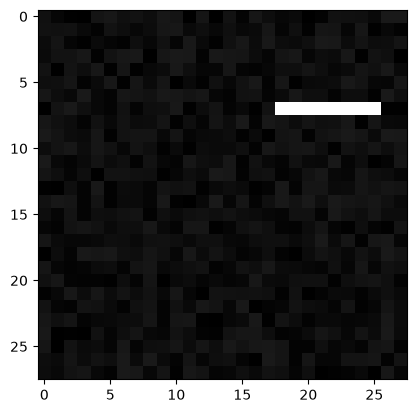

In [21]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
size = 28
img = 0.1 * rng.random((size, size))      # one noisy image

L = rng.integers(8, 13)                   # line length: 8..12
r = rng.integers(0, size)                 # row of the line
c = rng.integers(0, size - L + 1)         # start column (the line must fit in the image)

img[r, c:c+L] = 1.0                       # horizontal line: one row, L columns

plt.imshow(img, cmap="gray")
plt.show()

In [22]:
def generate_lines_data(n_samples, size=28, region="full", noise=0.1, seed=0):
    """Images with background noise and one line. Class 0 = horizontal, class 1 = vertical.
    region: 'left' / 'right' / 'full' -> which columns the line is allowed to occupy."""
    rng = np.random.default_rng(seed)
    X = noise * rng.random((n_samples, size, size))      # noisy background
    y = rng.integers(0, 2, n_samples)                    # random class (0/1) for every image

    # allowed columns [lo, hi) for this region
    if region == "left":
        lo, hi = 0, size // 2                            # columns 0..13
    elif region == "right":
        lo, hi = size // 2, size                         # columns 14..27
    else:
        lo, hi = 0, size                                 # whole image

    for i in range(n_samples):
        L = rng.integers(8, 13)                          # line length: 8..12
        if y[i] == 0:                                    # horizontal line
            row = rng.integers(0, size)                  # any row
            col = rng.integers(lo, hi - L + 1)           # start column: whole line stays inside the region
            X[i, row, col:col+L] = 1.0
        else:                                            # vertical line
            col = rng.integers(lo, hi)                   # its single column must be inside the region
            row = rng.integers(0, size - L + 1)          # start row
            X[i, row:row+L, col] = 1.0

    X = X[..., np.newaxis]                               # (n, size, size) -> (n, size, size, 1)
    return X, y

In [23]:
X, y = generate_lines_data(200)
X.shape
X[0].shape

(28, 28, 1)

- Visualize a grid showing a few representative examples of each class.

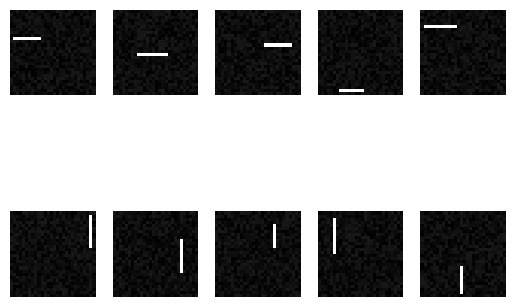

In [24]:
fig, axes = plt.subplots(2, 5)

# row 0: class 0
imgs0 = X[y == 0][:5]
for k in range(5):
    axes[0, k].imshow(imgs0[k, :, :, 0], cmap="gray")
    axes[0, k].axis("off")

# row 1: class 1
imgs1 = X[y == 1][:5]
for k in range(5):
    axes[1, k].imshow(imgs1[k, :, :, 0], cmap="gray")
    axes[1, k].axis("off")

plt.show()

Write `build_mlp(hidden_units)` and `build_cnn(filters, pooling)`.

- `filters` is a list, e.g., `[8, 16]`: each `Conv2D` layer is followed by a `MaxPooling(2)` layer.
- `pooling` accepts either `"flatten"` or `"global"`.
- Output: 1 neuron (`sigmoid` activation in Keras, raw logits paired with `BCEWithLogitsLoss` in PyTorch).

In [25]:
def build_mlp(hidden_units, size=28):
    layers = [Input(shape=(size, size, 1)), Flatten()]   # image -> one long vector
    for units in hidden_units:                           # [64, 32] -> 2 hidden layers
        layers.append(Dense(units, activation="relu"))
    layers.append(Dense(1, activation="sigmoid"))        # output: 1 neuron, probability of class 1
    return Sequential(layers)


def build_cnn(filters, pooling, size=28):
    layers = [Input(shape=(size, size, 1))]
    for f in filters:                                    # [8, 16] -> 2 conv blocks
        layers.append(Conv2D(f, (3, 3), activation="relu"))
        layers.append(MaxPooling2D(2))                   # each Conv2D is followed by MaxPooling(2)
    if pooling == "flatten":
        layers.append(Flatten())                         # keeps the position information
    elif pooling == "global":
        layers.append(GlobalMaxPooling2D())              # one number per filter, position is lost
    else:
        raise ValueError("pooling must be 'flatten' or 'global'")
    layers.append(Dense(1, activation="sigmoid"))
    return Sequential(layers)

Implement `train_model(...)` that returns the training history as a dictionary with the keys: `loss`, `val_loss`, `accuracy`, and `val_accuracy`. In PyTorch, write the training loop manually, but keep the return format identical so that `plot_history` works seamlessly across both frameworks.

In [26]:
def train_model(model, X_train, y_train, X_val, y_val, epochs=20, batch_size=32):
    model.compile(optimizer="adam",
                  loss="binary_crossentropy",       # model ends with sigmoid
                  metrics=["accuracy"])
    history = model.fit(X_train, y_train,
                        validation_data=(X_val, y_val),
                        epochs=epochs, batch_size=batch_size, verbose=0)
    return history.history

In [27]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(history["loss"], label="train")
    ax1.plot(history["val_loss"], label="val")
    ax1.set_title(f"{title} loss"); ax1.set_xlabel("epoch"); ax1.legend()
    ax2.plot(history["accuracy"], label="train")
    ax2.plot(history["val_accuracy"], label="val")
    ax2.set_title(f"{title} accuracy"); ax2.set_xlabel("epoch"); ax2.legend()
    plt.show()

- Train the MLP `[64]` and the CNN `[8, 16]` with `"flatten"` for 10 epochs. Plot the training curves and compile a comparison table containing: total parameter count and test accuracy.

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X, y = generate_lines_data(1000)

# split: take 20% away as the final test set
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# split: from the rest take 20% as validation
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=42)

In [30]:
import pandas as pd

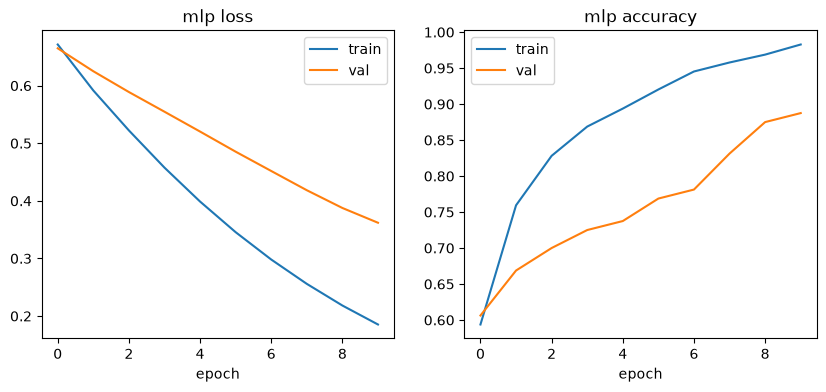

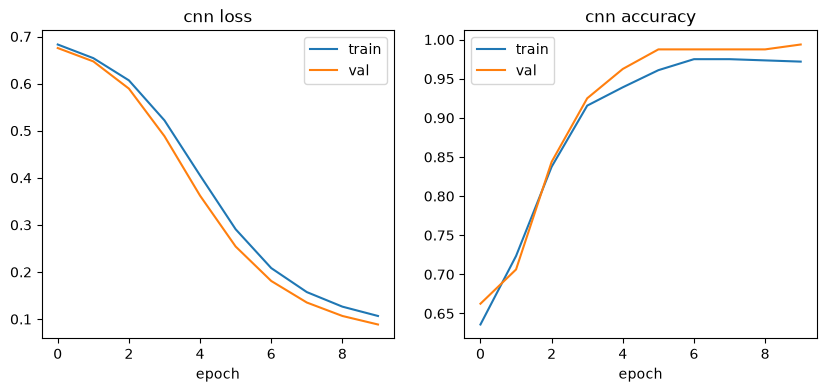

In [31]:
# training mlp
mlp = build_mlp([64])

# training cnn
cnn = build_cnn([8, 16], "flatten")

hist_mlp = train_model(mlp, X_train, y_train, X_val, y_val, epochs=10)

hist_cnn = train_model(cnn, X_train, y_train, X_val, y_val, epochs=10)
# showing results 
plot_history(hist_mlp, "mlp")
plot_history(hist_cnn, "cnn")

In [32]:
# MLP

loss, acc = mlp.evaluate(X_test, y_test, verbose=0)
params = mlp.count_params()

print(f"MLP acc {acc} and num of params {params}")

MLP acc 0.8399999737739563 and num of params 50305


In [33]:
# CNN

loss, acc = cnn.evaluate(X_test, y_test, verbose=0)
params = cnn.count_params()

print(f"CNN acc {acc} and num of params {params}")

CNN acc 0.9449999928474426 and num of params 1649


The CNN reaches ~96% validation accuracy with 1,649 parameters, while the MLP needs 50,305 parameters and still only reaches ~87%. 

The MLP overfits (train 0.98 vs val 0.87) because it has no built-in notion of spatial structure and must learn each pixel weight separately. The CNN shares one small filter across the whole image, so it generalizes better with far fewer parameters.

# Task 25: Translation, the True Advantage of CNNs

Train on the left half of the image and test on the right half.

- Generate a training dataset using `region="left"` and two separate test sets: `region="left"` and `region="right"`.
- Train three models:
  1. `MLP [64]`
  2. `CNN [8, 16]` with `"flatten"`
  3. `CNN [8, 16]` with `"global"` (`GlobalMaxPooling`)
- Compile a summary table reporting for each model: total parameter count, test accuracy on the `"left"` dataset, and test accuracy on the `"right"` dataset.
- Plot a bar chart comparing `"left"` vs. `"right"` test accuracy across all three models.
- Display a sample grid of images from the `"right"` test set that the MLP misclassifies.

### Questions to answer:
- Why does the MLP perform roughly at random-guessing level on the right side?
- Why does the CNN with Flatten also lose performance, while the CNN with Global Pooling does not?
- What is the difference between translational equivariance in convolution and translation invariance?

- Generate a training dataset using `region="left"` and two separate test sets: `region="left"` and `region="right"`.
- Train three models:
  1. `MLP [64]`
  2. `CNN [8, 16]` with `"flatten"`
  3. `CNN [8, 16]` with `"global"` (`GlobalMaxPooling`)
- Compile a summary table reporting for each model: total parameter count, test accuracy on the `"left"` dataset, and test accuracy on the `"right"` dataset.

In [34]:
X_train, y_train = generate_lines_data(500, region="left",  seed=0)
X_val,   y_val   = generate_lines_data(200, region="left",  seed=1) 
X_test_left,  y_test_left  = generate_lines_data(500, region="left",  seed=2)
X_test_right, y_test_right = generate_lines_data(500, region="right", seed=3)

In [35]:
from tensorflow.keras.layers import GlobalMaxPooling2D

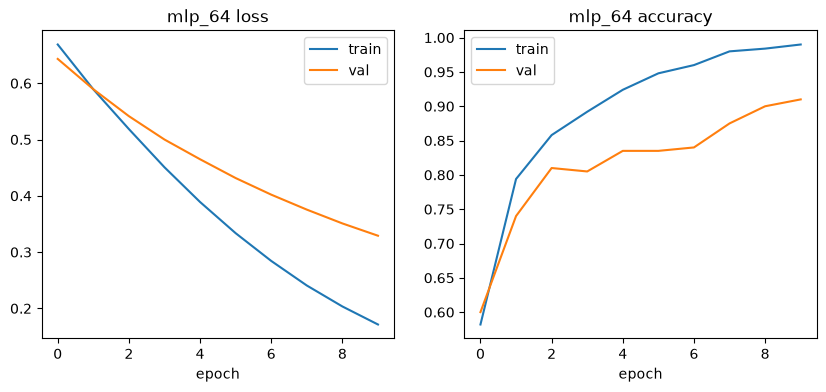

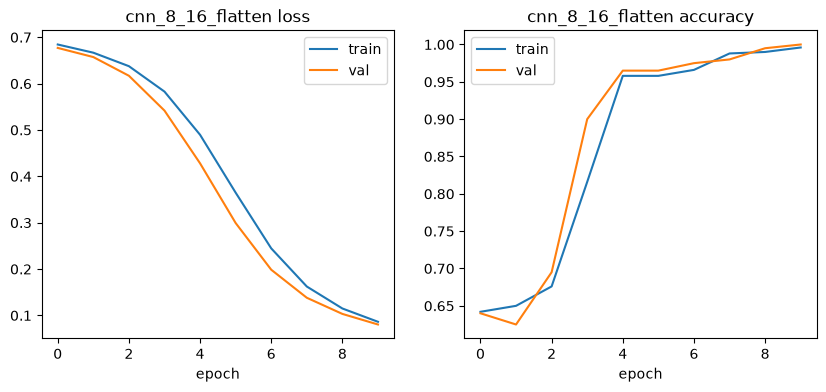

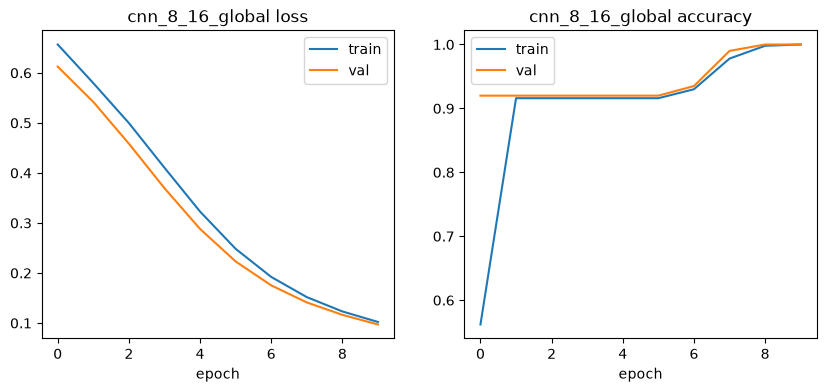

In [36]:
# training three models
mlp_2 = build_mlp([64])
cnn_2 = build_cnn([8, 16], "flatten")
cnn_3 = build_cnn([8, 16], "global")

hist_mlp_2 = train_model(mlp_2, X_train, y_train, X_val, y_val, epochs=10)
hist_cnn_2 = train_model(cnn_2, X_train, y_train, X_val, y_val, epochs=10)
hist_cnn_3 = train_model(cnn_3, X_train, y_train, X_val, y_val, epochs=10)

# plotting
plot_history(hist_mlp_2, "mlp_64")
plot_history(hist_cnn_2, "cnn_8_16_flatten")     
plot_history(hist_cnn_3, "cnn_8_16_global")  

In [37]:
# MLP 64
_, acc_left  = mlp_2.evaluate(X_test_left,  y_test_left,  verbose=0)
_, acc_right = mlp_2.evaluate(X_test_right, y_test_right, verbose=0)
print(f"MLP 64 params {mlp_2.count_params()}, left_acc {acc_left:.3f} right_acc {acc_right:.3f}")

# CNN 8_16_flatten
_, acc_left  = cnn_2.evaluate(X_test_left,  y_test_left,  verbose=0)
_, acc_right = cnn_2.evaluate(X_test_right, y_test_right, verbose=0)
print(f"CNN 8_16 flatten params {cnn_2.count_params()}, left_acc {acc_left:.3f} right_acc {acc_right:.3f}")

# CNN 8_16_global
_, acc_left  = cnn_3.evaluate(X_test_left,  y_test_left,  verbose=0)
_, acc_right = cnn_3.evaluate(X_test_right, y_test_right, verbose=0)
print(f"CNN 8_16 global params {cnn_3.count_params()}, left_acc {acc_left:.3f} right_acc {acc_right:.3f}")

MLP 64 params 50305, left_acc 0.910 right_acc 0.500
CNN 8_16 flatten params 1649, left_acc 0.998 right_acc 0.650
CNN 8_16 global params 1265, left_acc 1.000 right_acc 0.844


 Flatten + Dense reaches 100% on the training region but drops to 71% on unseen positions, because the Dense layer learns position-specific weights. The MLP drops to chance (47%) for the same reason. GlobalMaxPooling throws away position, so the CNN keeps 87% on the right half: a little less accurate where it trained, much more robust where it did not.

- Plot a bar chart comparing `"left"` vs. `"right"` test accuracy across all three models.


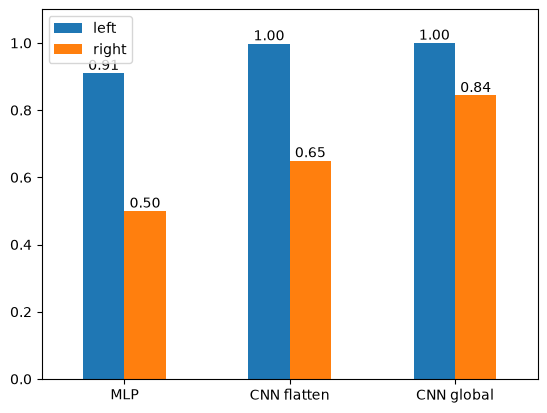

In [38]:
import pandas as pd

results = pd.DataFrame({
    "left":  [mlp_2.evaluate(X_test_left,  y_test_left,  verbose=0)[1],
              cnn_2.evaluate(X_test_left,  y_test_left,  verbose=0)[1],
              cnn_3.evaluate(X_test_left,  y_test_left,  verbose=0)[1]],
    "right": [mlp_2.evaluate(X_test_right, y_test_right, verbose=0)[1],
              cnn_2.evaluate(X_test_right, y_test_right, verbose=0)[1],
              cnn_3.evaluate(X_test_right, y_test_right, verbose=0)[1]],
}, index=["MLP", "CNN flatten", "CNN global"])

ax = results.plot.bar(ylim=(0, 1.1), rot=0)      
for bars in ax.containers:                       
    ax.bar_label(bars, fmt="%.2f")               

- Display a sample grid of images from the `"right"` test set that the MLP misclassifies.


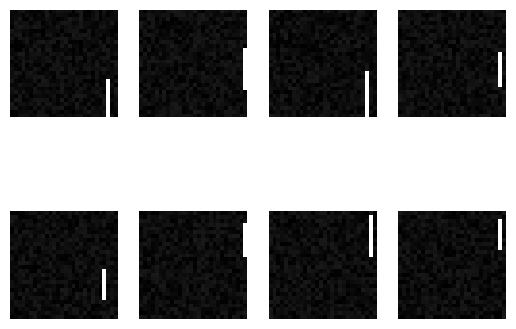

In [39]:
pred = (cnn_3.predict(X_test_right, verbose=0) > 0.5).ravel()
wrong = np.where(pred != y_test_right)[0][:8]

for k, i in enumerate(wrong):
    plt.subplot(2, 4, k + 1)                         # grid 2x4, k+1 = which cell
    plt.imshow(X_test_right[i, :, :, 0], cmap="gray")
    plt.axis("off")
plt.show()

### Questions to answer:
- Why does the MLP perform roughly at random-guessing level on the right side?
- Why does the CNN with Flatten also lose performance, while the CNN with Global Pooling does not?
- What is the difference between translational equivariance in convolution and translation invariance?

1, 2 The MLP and the Flatten-CNN learn where things are, so they fail in a region they never saw. Global pooling learns what the thing is, so it still works there.

3.  Equivariance: shift the input -> the output (feature map) shifts the same way.
(Conv2D) Invariance:   shift the input -> the output stays the same. (Global pooling on top)



## Task 26: What Did the Network See?
Peeking inside the trained neural network.

- Take the CNN model with `"global"` pooling from Task 25.
- Implement `plot_filters(model)` to visualize all learned $3 \times 3$ filters from the first convolutional layer.
- Implement `plot_feature_maps(model, image)` to visualize the first layer feature maps (post-ReLU activation). Run it on one sample with a horizontal line and one with a vertical line.
- Compare the learned filter weights with the handcrafted edge-detection kernels from Task 21.
- Experiment: construct a CNN consisting of a single convolutional layer followed by global pooling, varying the number of filters across: 1, 2, 4, 8, and 16. Train on `"left"` and evaluate on `"right"`. Generate a summary table with columns: number of filters, parameter count, and `"right"` test accuracy.

### Questions to answer:
- Does any learned filter resemble the handcrafted edge detector from Task 21?
- How many filters are genuinely sufficient to solve this task, and why?
- Compare this with your findings from Tasks 4 and 6: does larger capacity always mean better performance?

- Take the CNN model with `"global"` pooling from Task 25.
- Implement `plot_filters(model)` to visualize all learned $3 \times 3$ filters from the first convolutional layer.

In [40]:
cnn_3.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 11, 11, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 16)             │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,797 (14.84 KB)

 Trainable params: 1,265 (4.94 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,532 (9.89 KB)

In [41]:
def plot_filters(model):
    """Draw all 3x3 filters of the first Conv2D layer (red = negative, blue = positive weight)."""
    W, b = model.layers[0].get_weights()       # W shape: (3, 3, 1, n_filters)
    n = W.shape[-1]                            # number of filters
    vmax = abs(W).max()                        # one common colour scale for all filters

    cols = min(n, 4)                           # at most 4 filters per row
    rows = -(-n // cols)                       # rounded up: 8 -> 2 rows, 16 -> 4 rows
    fig, axes = plt.subplots(rows, cols, figsize=(2 * cols, 2 * rows), squeeze=False)

    for k, ax in enumerate(axes.ravel()):
        if k < n:                              # draw a filter only if there is one for this cell
            ax.imshow(W[:, :, 0, k], cmap="RdBu", vmin=-vmax, vmax=vmax)
            ax.set_title(f"filter {k}")
        ax.axis("off")                         # hide the axes in every cell, also the empty ones
    plt.show()

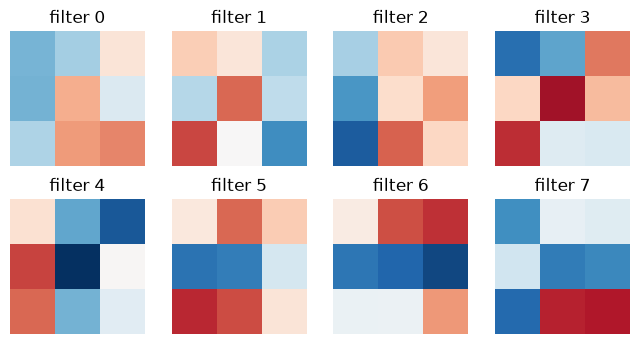

In [42]:
plot_filters(cnn_3)

### What the first-layer filters learned (CNN [8,16] + GlobalMaxPooling)

- The 8 learned 3x3 filters are **not clean hand-made detectors**: they start from random
  weights and training only nudges them, so several look like mixtures.
- Still, clear patterns appear: some filters respond to **vertical** structure
  (e.g. filter 5: a vertical stripe; filter 6: a left-to-right edge), one to a **horizontal**
  edge (filter 7: top vs bottom), one to a **diagonal** (filter 3). A few look noisy (1, 4).
- That is exactly what the task needs: telling a horizontal line from a vertical one.
- With `GlobalMaxPooling`, each filter is reduced to one number: *how strongly it fired
  anywhere in the image*. The final `Dense` layer weighs these 8 numbers, so the decision
  does not depend on **where** the line is. This is why the model still works on the
  right half it never saw during training.
- Filters are not perfectly clean and not all of them are needed: 8 filters is more than
  this simple task requires.

Implement `plot_feature_maps(model, image)` to visualize the first layer feature maps (post-ReLU activation). Run it on one sample with a horizontal line and one with a vertical line.

check the activation

In [44]:
for layer in cnn_3.layers:
    act = getattr(layer, "activation", None)           # pooling/flatten have no activation
    print(layer.name, layer.output.shape, act.__name__ if act else "-")

conv2d_13 (None, 26, 26, 8) relu
max_pooling2d_8 (None, 13, 13, 8) -
conv2d_14 (None, 11, 11, 16) relu
max_pooling2d_9 (None, 5, 5, 16) -
global_max_pooling2d (None, 16) -
dense_9 (None, 1) sigmoid


In [47]:
from tensorflow.keras import Model

In [48]:
def plot_feature_maps(model, image):
    first = Model(model.inputs, model.layers[0].output)         # model that stops after layer 0
    maps = first.predict(image[np.newaxis], verbose=0)[0]       # (26, 26, 8)
    for k in range(maps.shape[-1]):
        plt.subplot(2, 4, k + 1)
        plt.imshow(maps[:, :, k], cmap="gray")
        plt.axis("off")
    plt.show()

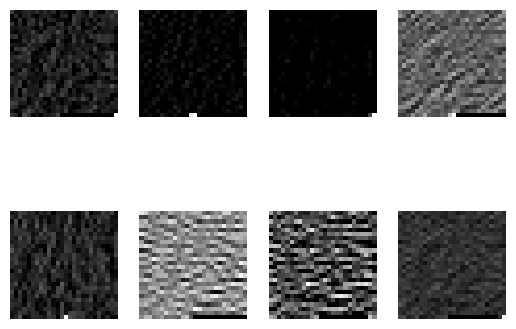

In [50]:
plot_feature_maps(cnn_3, X_test_right[y_test_right == 0][0])    # horizontal line

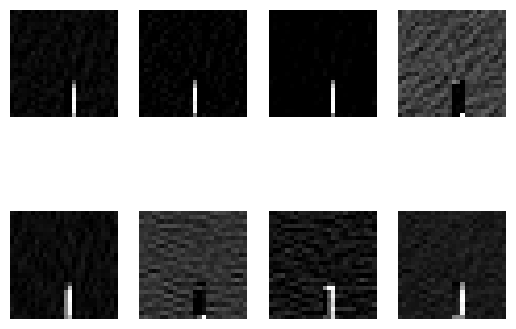

In [51]:
plot_feature_maps(cnn_3, X_test_right[y_test_right == 1][0])    # vertical line

- Compare the learned filter weights with the handcrafted edge-detection kernels from Task 21.


Filters from 21 exercise

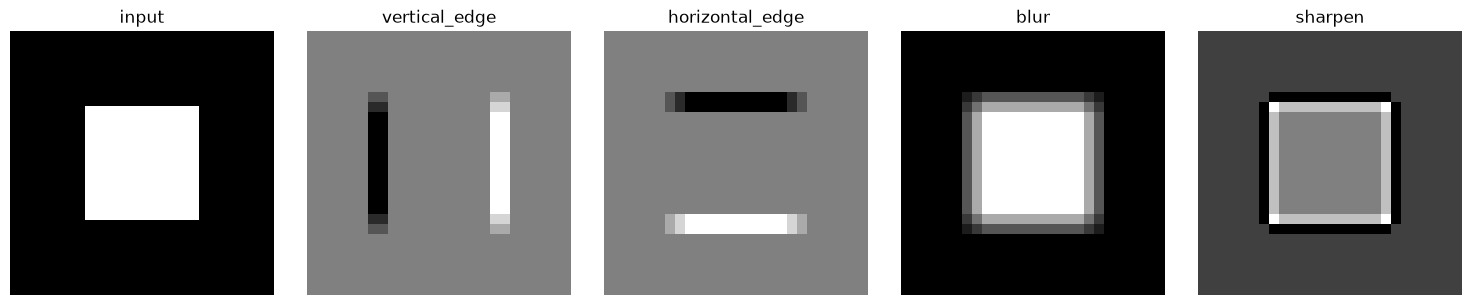

In [52]:
plot_images(images, titles)

Results of the handcrafted filters from Task 21 applied to the square image (for reference).


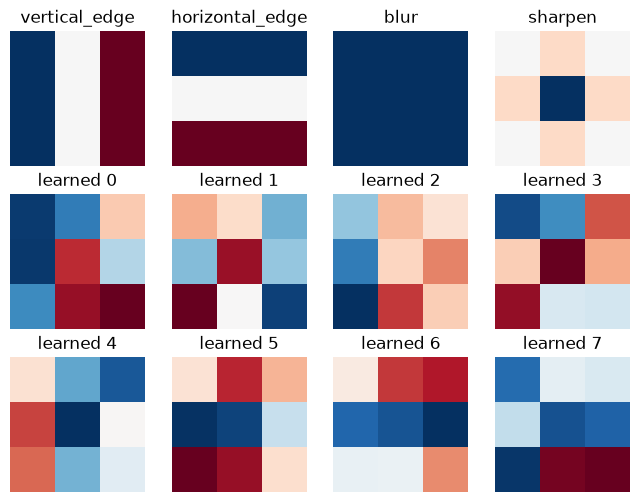

In [54]:
W, _ = cnn_3.layers[0].get_weights()

kernels = list(filters.values()) + [W[:, :, 0, k] for k in range(8)]
titles  = list(filters.keys())   + [f"learned {k}" for k in range(8)]

fig, axes = plt.subplots(3, 4, figsize=(8, 6))
for ax, kern, t in zip(axes.ravel(), kernels, titles):
    kern = np.array(kern, dtype=float)
    kern = kern / abs(kern).max()
    ax.imshow(kern, cmap="RdBu", vmin=-1, vmax=1)
    ax.set_title(t)
    ax.axis("off")
plt.show()

Experiment: construct a CNN consisting of a single convolutional layer followed by global pooling, varying the number of filters across: 1, 2, 4, 8, and 16. Train on `"left"` and evaluate on `"right"`. Generate a summary table with columns: number of filters, parameter count, and `"right"` test accuracy.

In [58]:
filters = [ 1, 2, 4, 8 ,16]
rows = []

for f in filters:
    cnn = build_cnn([f], "global")
    hist = train_model(cnn, X_train, y_train, X_val, y_val, epochs=10)
    _, acc_right = cnn.evaluate(X_test_right, y_test_right, verbose=0) 
    rows.append({"filters": f,
                 "params": cnn.count_params(),
                 "right acc": round(acc_right, 3)})

print(pd.DataFrame(rows))

   filters  params  right acc
0        1      12      0.538
1        2      23      0.942
2        4      45      0.612
3        8      89      0.972
4       16     177      0.962


model with 8 filters is the best 

### Questions to answer:
- Does any learned filter resemble the handcrafted edge detector from Task 21?
- How many filters are genuinely sufficient to solve this task, and why?
- Compare this with your findings from Tasks 4 and 6: does larger capacity always mean better performance?

In [61]:
1. tak np learned 7 przypomina horizontal edge 
2. wystarcza 2 bo juz osiagnelismy ponad 94 acc , reszta to juz taki dodatek
3. Nie przypkladem bylo MLP ktore mialo ponad 50 305 parametrow i acc na poziomie 0.47, ten sam problem rozwiazalo cnn z 89 parametrami na poziomie 97

SyntaxError: invalid syntax (4059789535.py, line 1)

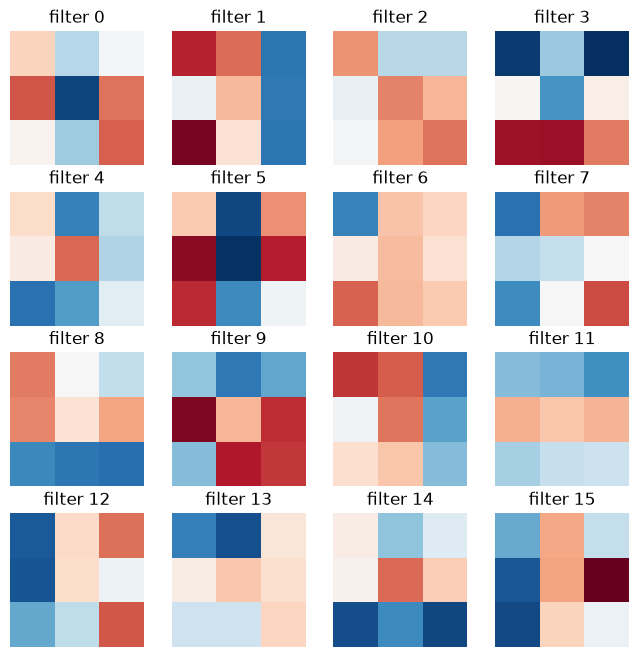

In [62]:
plot_filters(cnn)